# Statistical Analysis: Full-Resolution Training Supervision

**Purpose**: Load Phase 1 experiment results, compute summary statistics, run significance tests, and generate publication-ready tables/figures.

**Run on**: Local Mac (no GPU required, only needs `best_metrics.txt` files from Experiment_Repo)

---

**Experiment Design**:
- **Seeds**: `[42, 123, 2024]`
- **Configs**: Baseline, Full-Res
- **Architectures**: DeepLabV3 (R=8), SETR (R=16), SegFormer (R=4), UperNet+Swin (R=4), OneFormer (R=4)
- **Phase 1**: 5 arch × 2 configs × 3 seeds = 30 runs
- **Key Metrics**: IoU, F1, B-IoU, Precision, Recall, Pixel Accuracy

**Outputs**:
1. Summary table (mean ± std) for manuscript Table 2
2. Friedman test + Nemenyi post-hoc for manuscript Table 3
3. Bootstrap 95% CIs
4. Bar charts, B-IoU improvement plot, CI forest plots
5. LaTeX table exports

In [9]:
# ============================================================================
# Setup & Imports
# ============================================================================
import sys, os
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Set paths — detect project root robustly regardless of CWD
_cwd = Path(os.path.abspath(""))
if (_cwd / "Experiment_Repo").exists():
    ROOT_DIR = _cwd
elif (_cwd.parent.parent / "Experiment_Repo").exists():
    ROOT_DIR = _cwd.parent.parent
else:
    raise FileNotFoundError(
        f"Cannot locate project root (Experiment_Repo not found). CWD = {_cwd}"
    )

CODEBASE_DIR = ROOT_DIR / "Codebase"
EXPERIMENT_REPO_DIR = ROOT_DIR / "Experiment_Repo"
EXPORT_DIR = CODEBASE_DIR / "Notebook" / "exports"
EXPORT_DIR.mkdir(exist_ok=True)

# Plot style
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Root dir: {ROOT_DIR}")
print(f"Experiment repo: {EXPERIMENT_REPO_DIR}")
print(f"Exists: {EXPERIMENT_REPO_DIR.exists()}")

Root dir: /Volumes/Din's SSD for Mac/BARE_Journal
Experiment repo: /Volumes/Din's SSD for Mac/BARE_Journal/Experiment_Repo
Exists: True


---
## Part 1: Load & Aggregate Experiment Results

In [10]:
# ============================================================================
# Experiment Constants
# ============================================================================
SEEDS = [42, 123, 2024]
ARCHITECTURES = ["DeepLabV3", "SETR", "SegFormer", "UperNet+Swin", "OneFormer"]
CONFIGS = ["baseline", "full-res"]
REDUCTION_FACTORS = {"DeepLabV3": 8, "SETR": 16, "SegFormer": 4, "UperNet+Swin": 4, "OneFormer": 4}

KEY_METRICS = [
    "val_iou_class_1", "val_f1_score_class_1", "val_boundary_iou_class_1",
    "val_precision_class_1", "val_recall_class_1", "val_pixel_accuracy",
]
METRIC_DISPLAY = {
    "val_iou_class_1": "IoU",
    "val_f1_score_class_1": "F1",
    "val_boundary_iou_class_1": "B-IoU",
    "val_precision_class_1": "Precision",
    "val_recall_class_1": "Recall",
    "val_pixel_accuracy": "Pixel Acc",
}

ARCH_DIR_MAP = {
    "DeepLabV3": "DeepLabV3", "SETR": "SETR", "SegFormer": "SegFormer",
    "UperNet+Swin": "UperNet+Swin", "OneFormer": "OneFormer",
}
ARCH_PREFIX_MAP = {
    "DeepLabV3": "deeplabv3", "SETR": "setr", "SegFormer": "segformer",
    "UperNet+Swin": "upernet_swin", "OneFormer": "oneformer",
}

In [11]:
# ============================================================================
# Results Loader (best_metrics.txt only)
# ============================================================================

def parse_metrics_file(metrics_path: Path) -> Dict[str, float]:
    """Parse a best_metrics.txt file (format: 'key = value')."""
    metrics = {}
    with open(metrics_path) as f:
        for line in f:
            line = line.strip()
            if "=" in line:
                key, val = line.split("=", 1)
                try:
                    metrics[key.strip()] = float(val.strip())
                except ValueError:
                    pass
    return metrics


def find_best_metrics_for_run(run_dir: Path) -> Tuple[Dict[str, float], Optional[str]]:
    """
    Find and parse best_metrics.txt for a run directory.
    Handles both old (BARE_Notebook/) and new (Notebook/) directory layouts.
    Returns: (metrics_dict, best_checkpoint_path_or_None)
    """
    notebook_dirs = list(run_dir.glob("BARE_Notebook/outputs_*/")) + \
                    list(run_dir.glob("Notebook/outputs_*/"))
    for out_dir in notebook_dirs:
        best_ckpt_dir = out_dir / "best_checkpoint"
        best_path = best_ckpt_dir / "best_metrics.txt"
        if best_path.exists():
            return parse_metrics_file(best_path), str(best_ckpt_dir)
    return {}, None


def load_all_results(base_dir: Path) -> pd.DataFrame:
    """
    Scan Experiment_Repo and load all Phase 1 results from best_metrics.txt.
    """
    records = []
    skipped = []

    for arch_display, arch_dir_name in ARCH_DIR_MAP.items():
        arch_dir = base_dir / arch_dir_name
        if not arch_dir.exists():
            print(f"\u26a0\ufe0f Architecture directory not found: {arch_dir}")
            continue

        prefix = ARCH_PREFIX_MAP[arch_display]

        for run_dir in sorted(arch_dir.iterdir()):
            if not run_dir.is_dir() or run_dir.name.startswith("."):
                continue
            dirname = run_dir.name.lower()

            if f"{prefix}_baseline_" in dirname:
                config_name = "baseline"
            elif f"{prefix}_fullres_" in dirname or f"{prefix}_full_res_" in dirname:
                config_name = "full-res"
            else:
                continue

            parts = dirname.replace(f"{prefix}_baseline_", "").replace(
                f"{prefix}_fullres_", "").replace(f"{prefix}_full_res_", "")
            seed_str = parts.split("_")[0]
            try:
                seed = int(seed_str)
            except ValueError:
                continue
            if seed not in SEEDS:
                continue

            metrics, model_path = find_best_metrics_for_run(run_dir)
            if not metrics:
                skipped.append(f"{arch_display}/{run_dir.name}")
                continue

            row = {"architecture": arch_display, "config": config_name,
                   "seed": seed, "run_dir": str(run_dir), "model_path": model_path}
            row.update(metrics)
            records.append(row)

    if skipped:
        print(f"\n\u26a0\ufe0f Skipped {len(skipped)} runs (no best_metrics.txt):")
        for s in skipped:
            print(f"    {s}")

    if not records:
        print("\u26a0\ufe0f No completed runs found.")
        return pd.DataFrame()

    df = pd.DataFrame(records)
    print(f"\nLoaded {len(df)} results (source: best_metrics.txt)")
    print(f"Architectures: {sorted(df['architecture'].unique().tolist())}")
    print(f"Configs: {sorted(df['config'].unique().tolist())}")
    print(f"Seeds: {sorted(df['seed'].unique().tolist())}")
    print(f"\nCompleteness (expected {len(SEEDS)} per cell):")
    print(df.groupby(["architecture", "config"]).size().unstack(fill_value=0).to_string())
    return df


df_results = load_all_results(EXPERIMENT_REPO_DIR)
if not df_results.empty:
    display_cols = ["architecture", "config", "seed"] + \
                   [m for m in KEY_METRICS if m in df_results.columns]
    display(df_results[display_cols].sort_values(
        ["architecture", "config", "seed"]).reset_index(drop=True))


Loaded 30 results (source: best_metrics.txt)
Architectures: ['DeepLabV3', 'OneFormer', 'SETR', 'SegFormer', 'UperNet+Swin']
Configs: ['baseline', 'full-res']
Seeds: [42, 123, 2024]

Completeness (expected 3 per cell):
config        baseline  full-res
architecture                    
DeepLabV3            3         3
OneFormer            3         3
SETR                 3         3
SegFormer            3         3
UperNet+Swin         3         3


,architecture,config,seed,val_iou_class_1,val_f1_score_class_1,val_boundary_iou_class_1,val_precision_class_1,val_recall_class_1,val_pixel_accuracy
0,DeepLabV3,baseline,42,0.8398,0.9129,0.5534,0.9077,0.9182,0.9580
1,DeepLabV3,baseline,123,0.8150,0.8981,0.4988,0.8880,0.9083,0.9462
2,DeepLabV3,baseline,2024,0.8368,0.9111,0.5586,0.9147,0.9076,0.9548
3,DeepLabV3,full-res,42,0.8056,0.8924,0.5526,0.8906,0.8941,0.9501
4,DeepLabV3,full-res,123,0.8292,0.9066,0.5207,0.9023,0.9111,0.9514
5,DeepLabV3,full-res,2024,0.8442,0.9155,0.5661,0.9179,0.9132,0.9585
6,OneFormer,baseline,42,0.8858,0.9395,0.6687,0.9457,0.9333,0.9705
7,OneFormer,baseline,123,0.9015,0.9482,0.6649,0.9531,0.9433,0.9736
8,OneFormer,baseline,2024,0.8893,0.9414,0.6768,0.9453,0.9375,0.9707
9,OneFormer,full-res,42,0.8897,0.9416,0.6721,0.9403,0.9429,0.9712


In [12]:
# ============================================================================
# Aggregate Results: Mean +/- Std across seeds
# ============================================================================

def aggregate_results(df: pd.DataFrame, metrics: List[str] = None) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    if metrics is None:
        metrics = [m for m in KEY_METRICS if m in df.columns]
    agg_dict = {m: ["mean", "std", "count"] for m in metrics}
    grouped = df.groupby(["architecture", "config"]).agg(agg_dict)
    grouped.columns = [f"{m}_{stat}" for m, stat in grouped.columns]
    return grouped.reset_index()


def format_mean_std(mean: float, std: float, decimals: int = 4) -> str:
    if pd.isna(mean):
        return "---"
    if pd.isna(std) or std == 0:
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} \u00b1 {std:.{decimals}f}"


def create_summary_table(df_agg: pd.DataFrame) -> pd.DataFrame:
    if df_agg.empty:
        return pd.DataFrame()
    rows = []
    for _, row in df_agg.iterrows():
        entry = {
            "Architecture": row["architecture"],
            "Config": "Baseline" if row["config"] == "baseline" else "Full-Res",
        }
        for metric_key, display_name in METRIC_DISPLAY.items():
            mean_col = f"{metric_key}_mean"
            std_col = f"{metric_key}_std"
            count_col = f"{metric_key}_count"
            if mean_col in row.index:
                entry[display_name] = format_mean_std(row[mean_col], row[std_col])
                entry[f"{display_name} (n)"] = int(row[count_col]) if count_col in row.index else 0
            else:
                entry[display_name] = "---"
        rows.append(entry)
    return pd.DataFrame(rows)


if not df_results.empty:
    df_agg = aggregate_results(df_results)
    df_summary = create_summary_table(df_agg)
    display(df_summary)
else:
    df_agg = pd.DataFrame()
    df_summary = pd.DataFrame()
    print("No results to aggregate.")

,Architecture,Config,IoU,IoU (n),F1,F1 (n),B-IoU,B-IoU (n),Precision,Precision (n),Recall,Recall (n),Pixel Acc,Pixel Acc (n)
0,DeepLabV3,Baseline,0.8305 ± 0.0135,3,0.9074 ± 0.0081,3,0.5369 ± 0.0331,3,0.9035 ± 0.0138,3,0.9114 ± 0.0059,3,0.9530 ± 0.0061,3
1,DeepLabV3,Full-Res,0.8263 ± 0.0195,3,0.9048 ± 0.0117,3,0.5465 ± 0.0233,3,0.9036 ± 0.0137,3,0.9061 ± 0.0105,3,0.9533 ± 0.0045,3
2,OneFormer,Baseline,0.8922 ± 0.0082,3,0.9430 ± 0.0046,3,0.6701 ± 0.0061,3,0.9480 ± 0.0044,3,0.9380 ± 0.0050,3,0.9716 ± 0.0017,3
3,OneFormer,Full-Res,0.8963 ± 0.0077,3,0.9453 ± 0.0043,3,0.6774 ± 0.0090,3,0.9473 ± 0.0070,3,0.9432 ± 0.0024,3,0.9726 ± 0.0017,3
4,SETR,Baseline,0.8525 ± 0.0061,3,0.9204 ± 0.0035,3,0.5364 ± 0.0226,3,0.9307 ± 0.0080,3,0.9104 ± 0.0014,3,0.9608 ± 0.0014,3
5,SETR,Full-Res,0.8880 ± 0.0053,3,0.9407 ± 0.0030,3,0.6410 ± 0.0268,3,0.9472 ± 0.0067,3,0.9343 ± 0.0080,3,0.9711 ± 0.0006,3
6,SegFormer,Baseline,0.8691 ± 0.0100,3,0.9299 ± 0.0057,3,0.6069 ± 0.0108,3,0.9312 ± 0.0046,3,0.9287 ± 0.0075,3,0.9653 ± 0.0014,3
7,SegFormer,Full-Res,0.8719 ± 0.0098,3,0.9316 ± 0.0056,3,0.6136 ± 0.0114,3,0.9324 ± 0.0042,3,0.9308 ± 0.0080,3,0.9661 ± 0.0013,3
8,UperNet+Swin,Baseline,0.8878 ± 0.0043,3,0.9405 ± 0.0024,3,0.6380 ± 0.0073,3,0.9448 ± 0.0061,3,0.9363 ± 0.0013,3,0.9701 ± 0.0005,3
9,UperNet+Swin,Full-Res,0.8850 ± 0.0089,3,0.9390 ± 0.0050,3,0.6401 ± 0.0123,3,0.9400 ± 0.0109,3,0.9380 ± 0.0009,3,0.9693 ± 0.0016,3


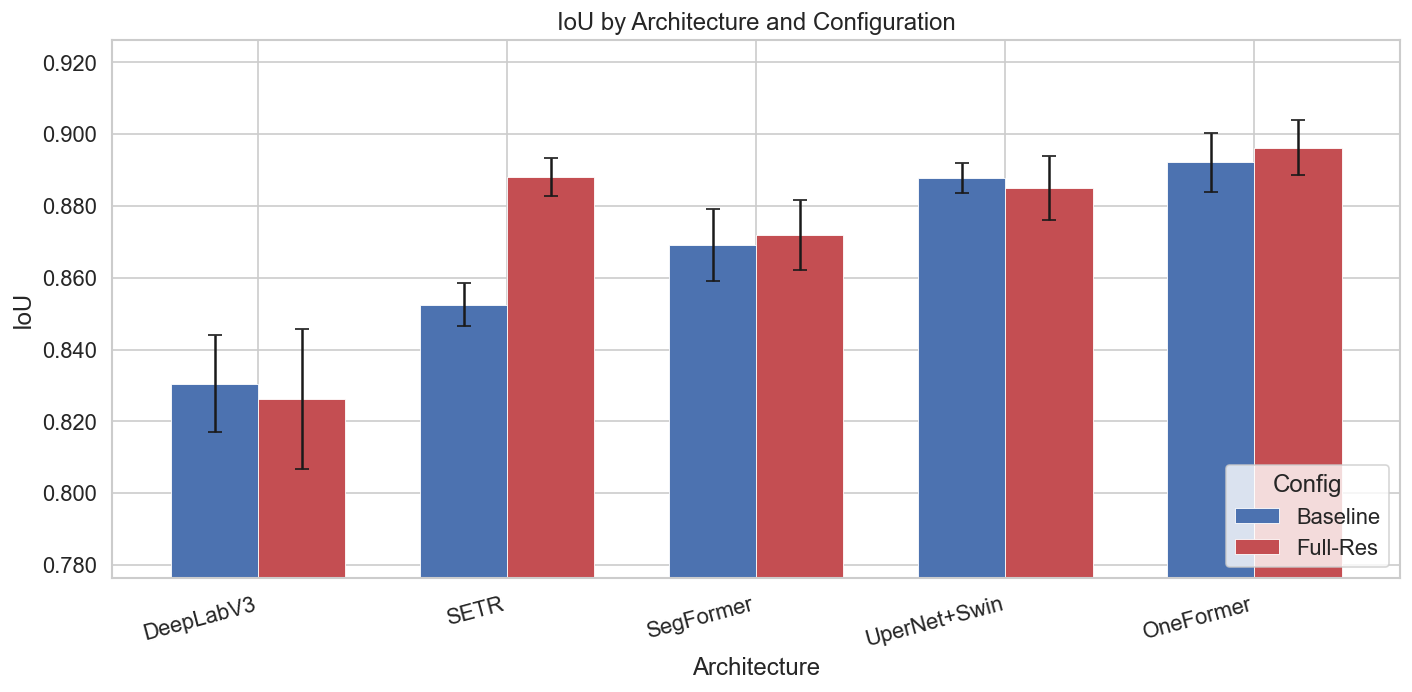

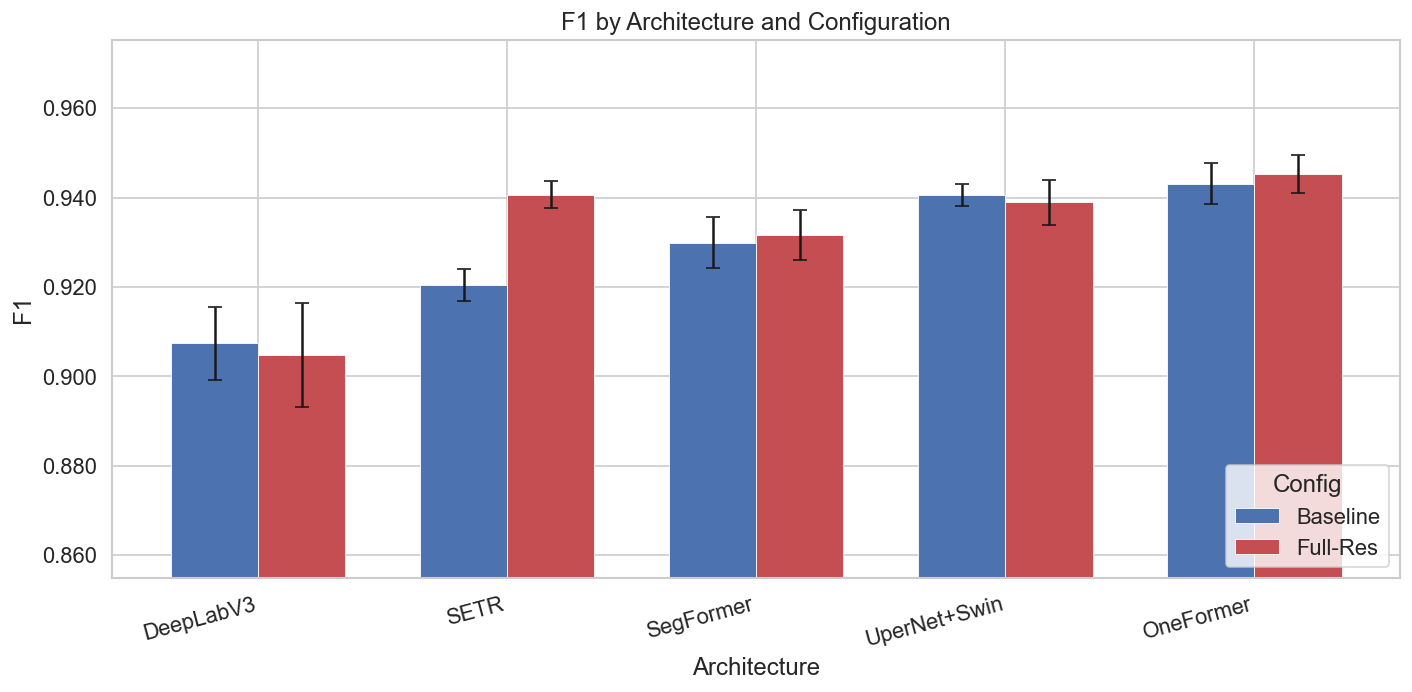

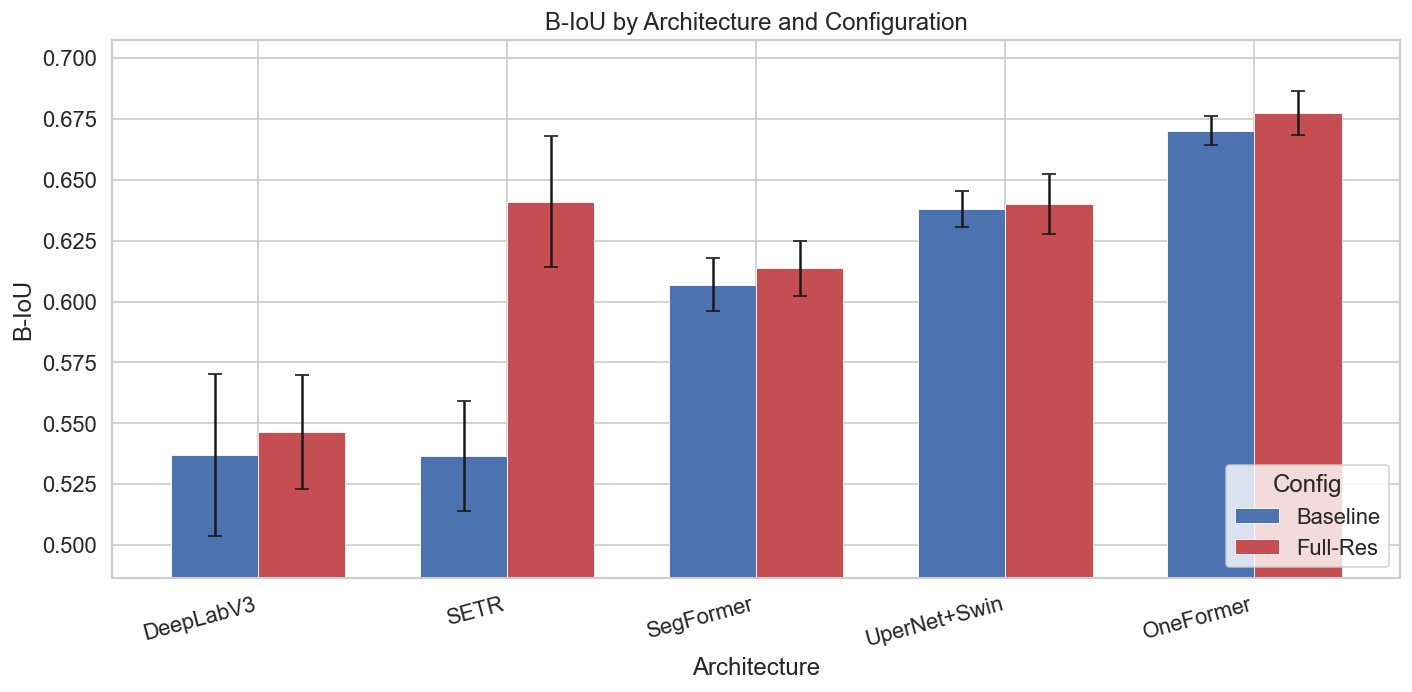

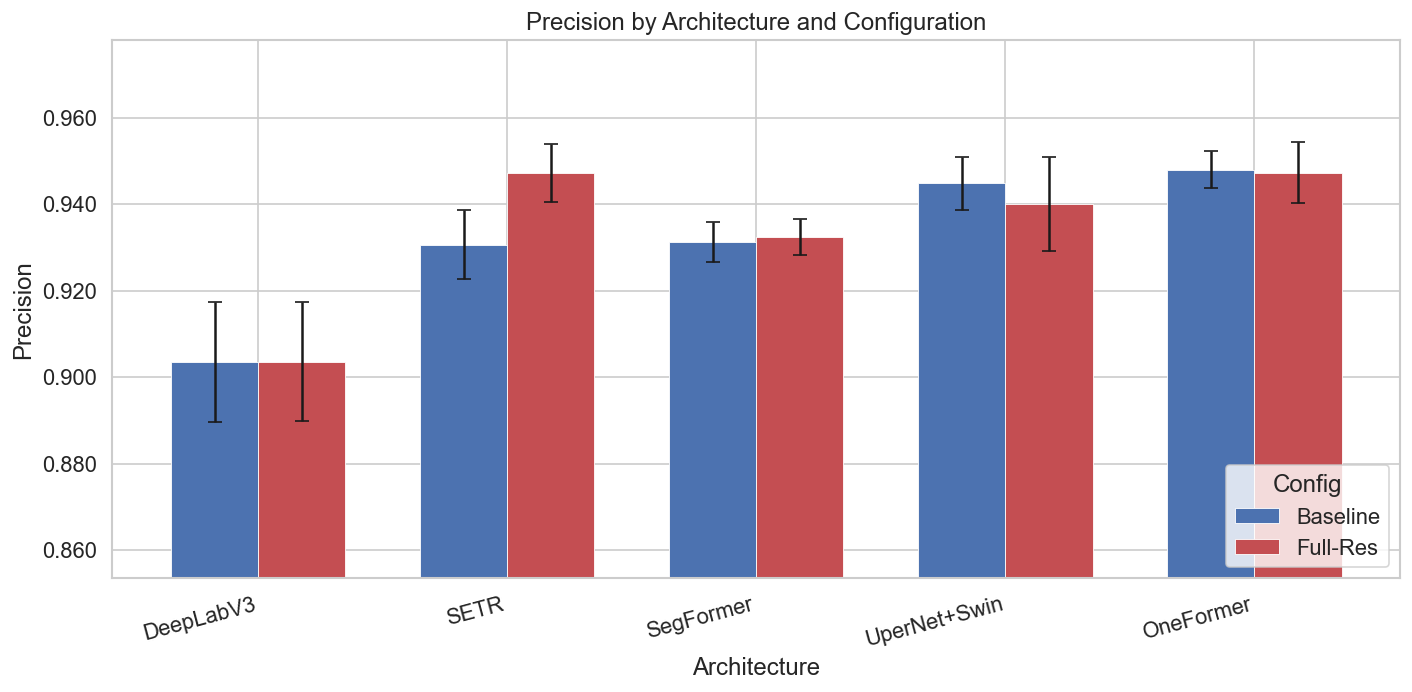

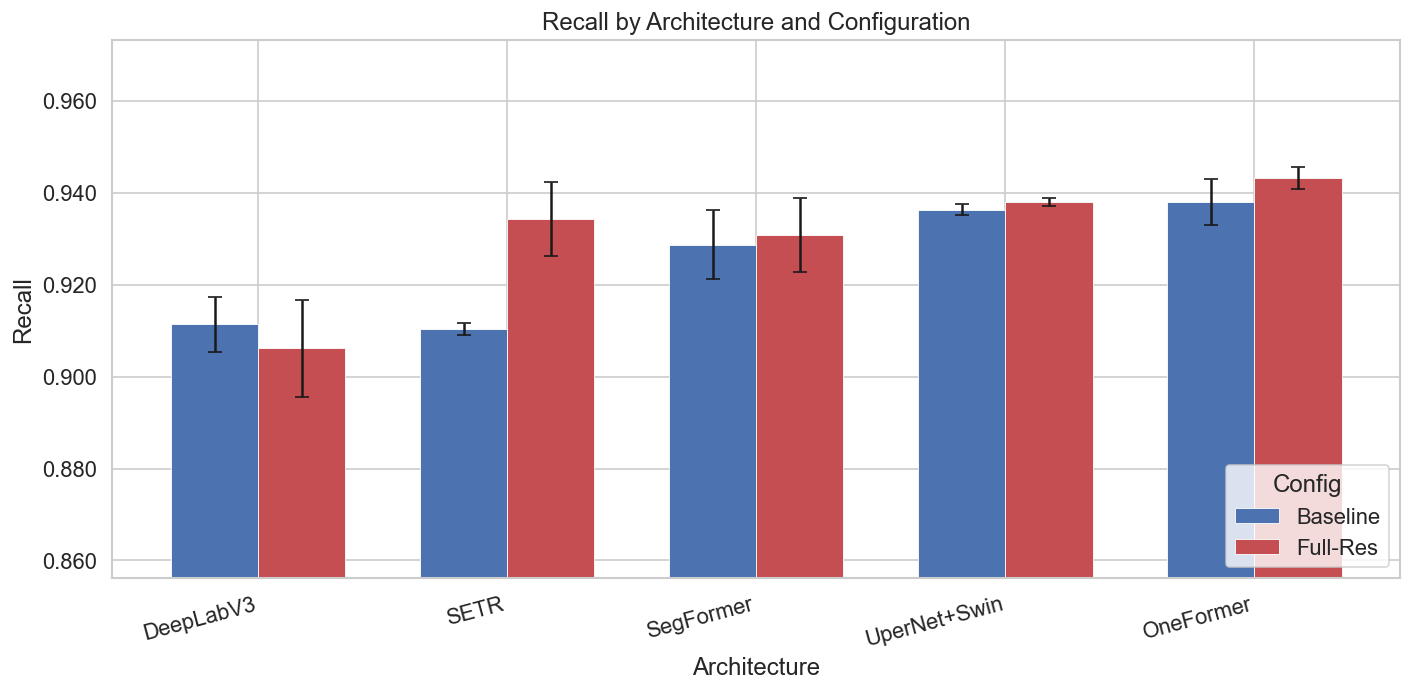

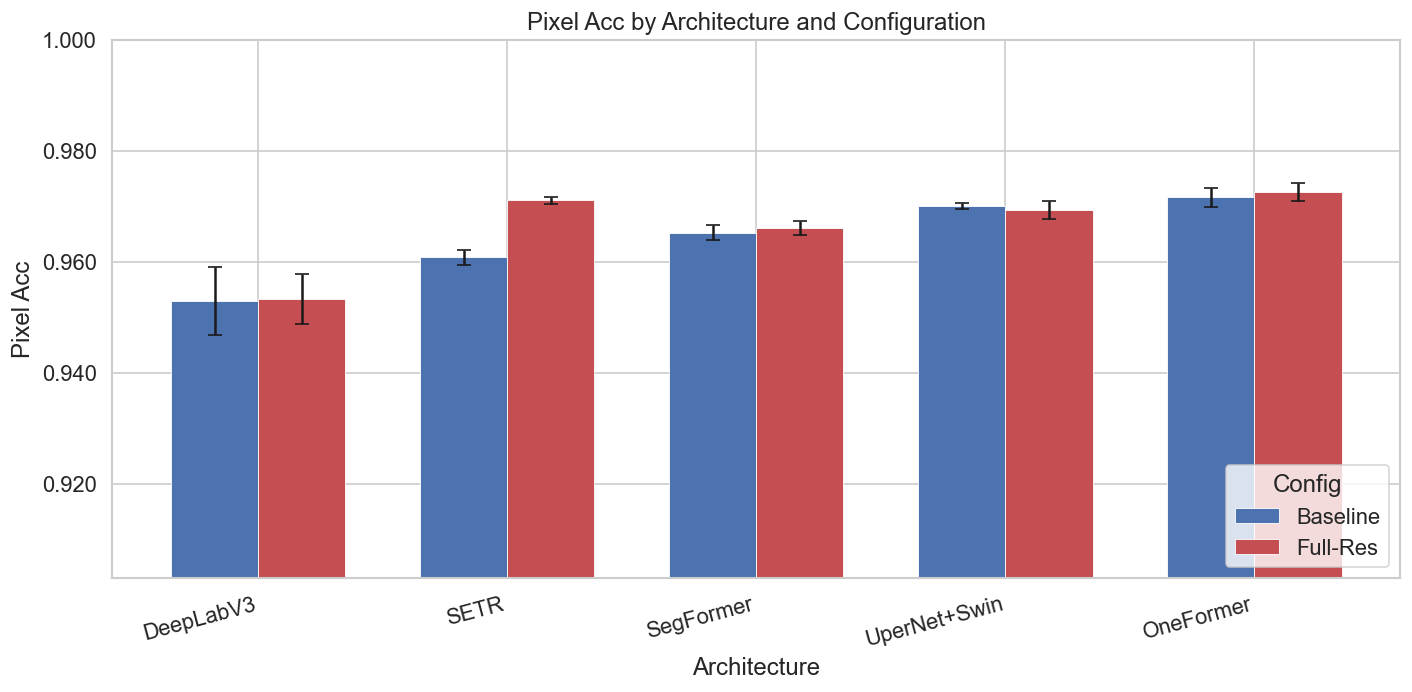

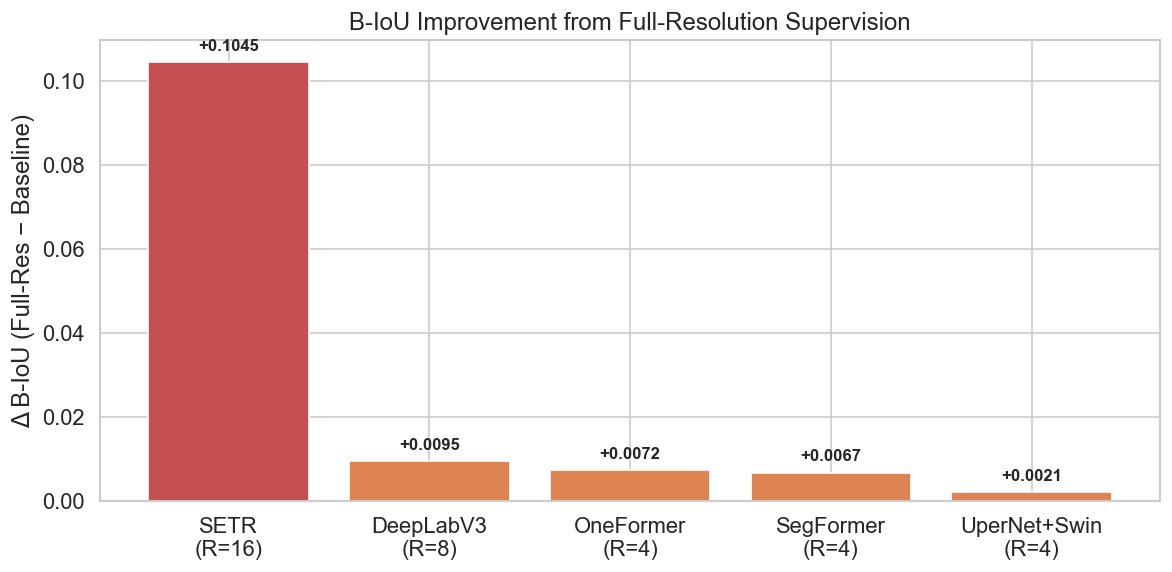

In [13]:
# ============================================================================
# Bar Charts: Baseline vs Full-Res per architecture
# ============================================================================

def plot_metric_comparison(df, metric_key, display_name, title=None, save_path=None):
    if df.empty or metric_key not in df.columns:
        return
    pivot = df.groupby(["architecture", "config"])[metric_key].agg(["mean", "std"]).reset_index()
    architectures = [a for a in ARCHITECTURES if a in pivot["architecture"].unique()]
    configs = [c for c in CONFIGS if c in pivot["config"].unique()]
    config_labels = {"baseline": "Baseline", "full-res": "Full-Res"}
    config_colors = {"baseline": "#4C72B0", "full-res": "#C44E52"}

    x = np.arange(len(architectures))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, cfg in enumerate(configs):
        cfg_data = pivot[pivot["config"] == cfg]
        means, stds = [], []
        for arch in architectures:
            row = cfg_data[cfg_data["architecture"] == arch]
            means.append(row["mean"].values[0] if not row.empty else 0)
            stds.append(row["std"].values[0] if not row.empty and not pd.isna(row["std"].values[0]) else 0)
        ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4,
               label=config_labels.get(cfg, cfg), color=config_colors.get(cfg, "gray"),
               edgecolor="white", linewidth=0.5)

    ax.set_xlabel("Architecture")
    ax.set_ylabel(display_name)
    ax.set_title(title or f"{display_name} by Architecture and Configuration")
    ax.set_xticks(x)
    ax.set_xticklabels(architectures, rotation=15, ha='right')
    ax.legend(title="Config", loc="lower right")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    all_vals = pivot["mean"].dropna()
    if len(all_vals) > 0:
        ax.set_ylim(max(0, all_vals.min() - 0.05), min(1.0, all_vals.max() + 0.03))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


def plot_biou_improvement(df, save_path=None):
    metric_key = "val_boundary_iou_class_1"
    if df.empty or metric_key not in df.columns:
        return
    means = df.groupby(["architecture", "config"])[metric_key].mean().unstack()
    if "baseline" not in means.columns or "full-res" not in means.columns:
        return
    delta = (means["full-res"] - means["baseline"]).sort_values(ascending=False)
    labels = [f"{a}\n(R={REDUCTION_FACTORS.get(a, '?')})" for a in delta.index]
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#C44E52' if v > 0.01 else '#DD8452' if v > 0 else '#4C72B0' for v in delta.values]
    bars = ax.bar(range(len(delta)), delta.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(delta)))
    ax.set_xticklabels(labels)
    ax.set_ylabel("\u0394 B-IoU (Full-Res \u2212 Baseline)")
    ax.set_title("B-IoU Improvement from Full-Resolution Supervision")
    ax.axhline(y=0, color='black', linewidth=0.5)
    for bar, val in zip(bars, delta.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"+{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


if not df_results.empty:
    for mk, dn in METRIC_DISPLAY.items():
        if mk in df_results.columns:
            plot_metric_comparison(df_results, mk, dn,
                                  save_path=str(EXPORT_DIR / f"bar_{dn.lower().replace('-', '_').replace(' ', '_')}.pdf"))
    plot_biou_improvement(df_results, save_path=str(EXPORT_DIR / "bar_biou_improvement.pdf"))

---
## Part 2: Statistical Significance Testing

**Tests**:
1. **Friedman Test** (5 architectures, 3 seeds as blocks) per config
2. **Nemenyi Post-Hoc** with critical difference diagrams
3. **Bootstrap 95% CIs** per (architecture, config)
4. **Paired difference analysis** (Baseline vs Full-Res per architecture)


Cross-Architecture Comparison (BASELINE)

  IoU: χ²=11.4667, p=0.021791, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.3333333333333333, 'SETR': 4.0, 'SegFormer': 3.0, 'UperNet+Swin': 1.6666666666666667}
    Nemenyi CD (α=0.05): 3.5218


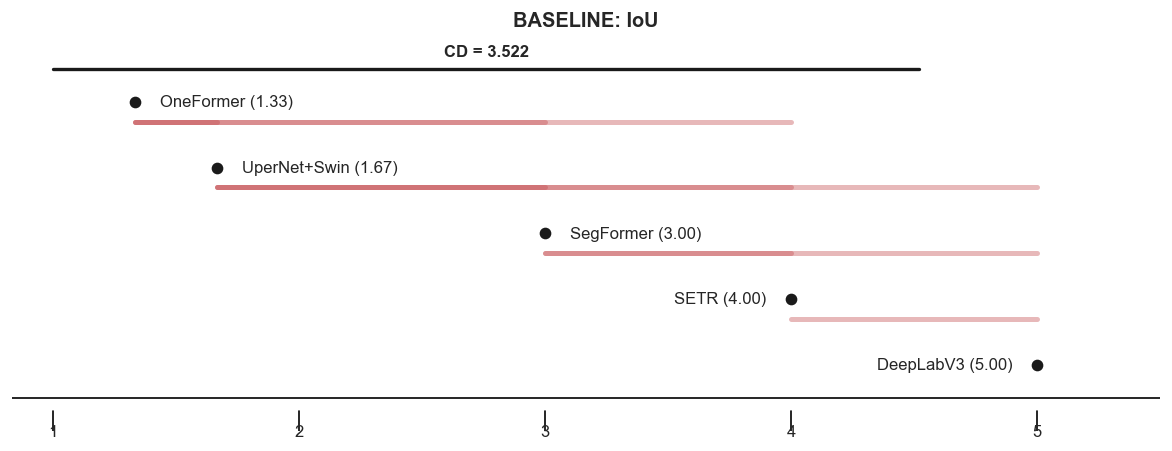


  F1: χ²=11.4667, p=0.021791, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.3333333333333333, 'SETR': 4.0, 'SegFormer': 3.0, 'UperNet+Swin': 1.6666666666666667}
    Nemenyi CD (α=0.05): 3.5218


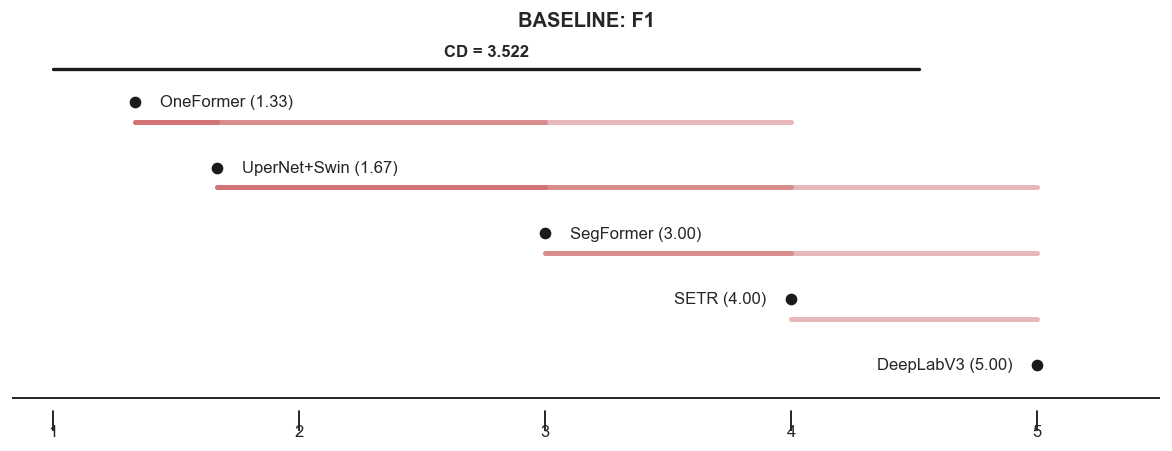


  B-IoU: χ²=11.4667, p=0.021791, Significant: YES
    Avg ranks: {'DeepLabV3': 4.333333333333333, 'OneFormer': 1.0, 'SETR': 4.666666666666667, 'SegFormer': 3.0, 'UperNet+Swin': 2.0}
    Nemenyi CD (α=0.05): 3.5218


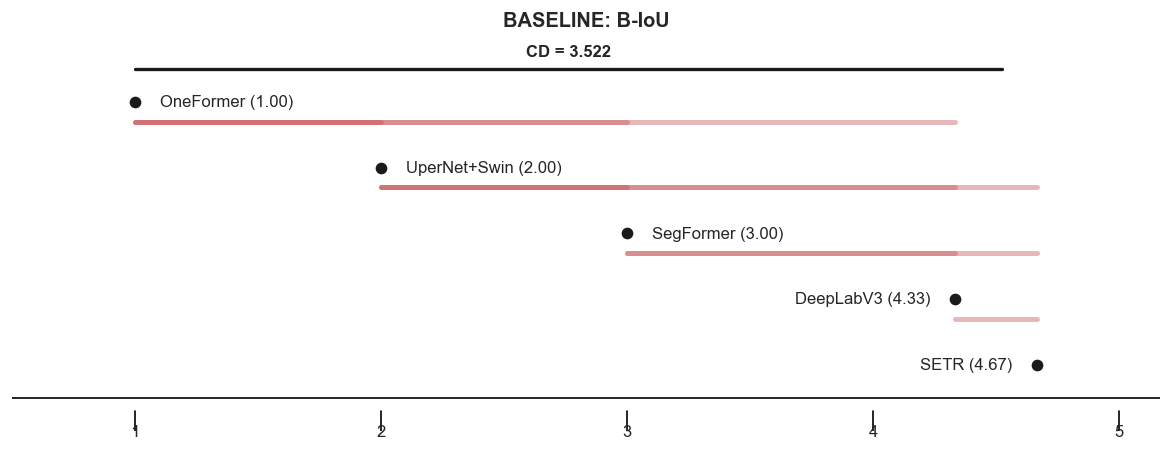


  Precision: χ²=11.4667, p=0.021791, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 3.3333333333333335, 'SegFormer': 3.6666666666666665, 'UperNet+Swin': 2.0}
    Nemenyi CD (α=0.05): 3.5218


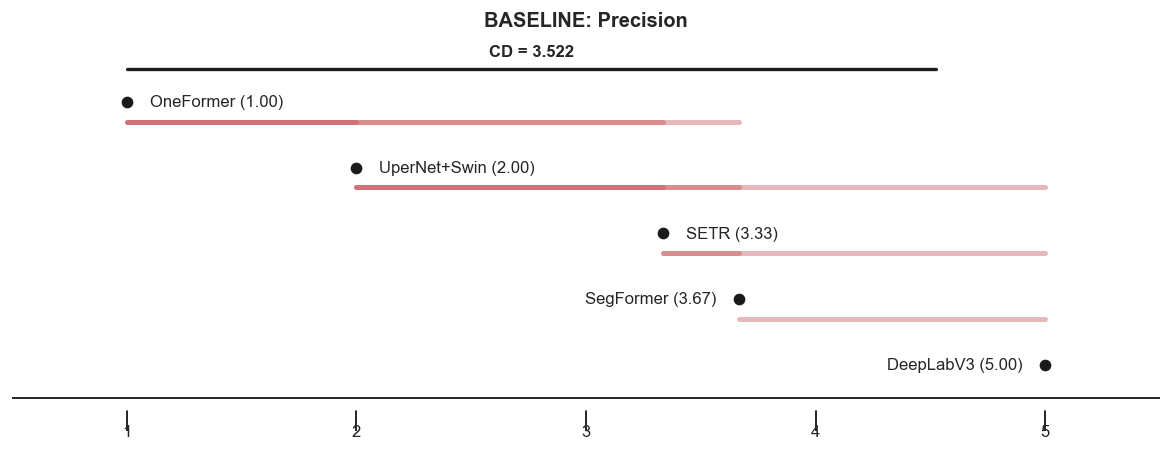


  Recall: χ²=10.1333, p=0.038241, Significant: YES
    Avg ranks: {'DeepLabV3': 4.666666666666667, 'OneFormer': 1.3333333333333333, 'SETR': 4.333333333333333, 'SegFormer': 2.6666666666666665, 'UperNet+Swin': 2.0}
    Nemenyi CD (α=0.05): 3.5218


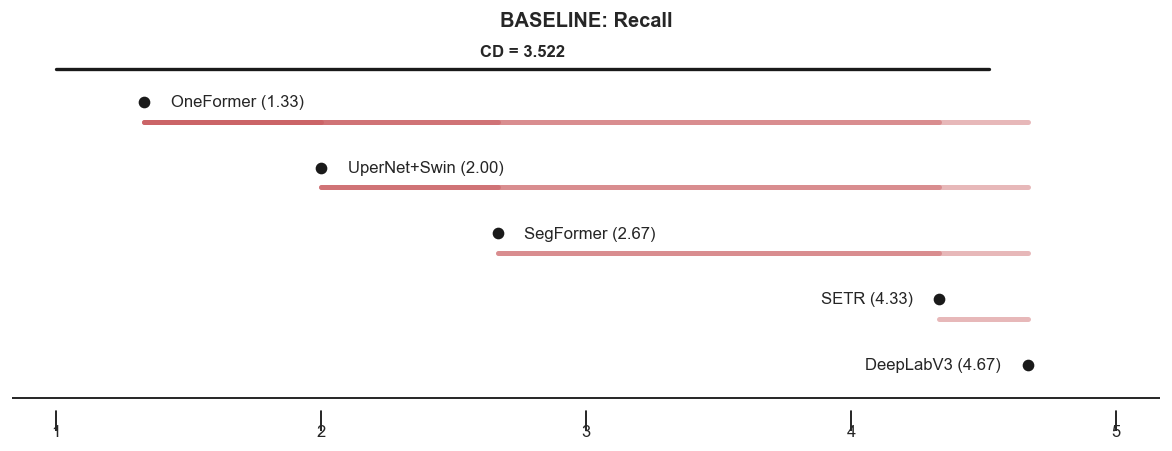


  Pixel Acc: χ²=12.0000, p=0.017351, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 4.0, 'SegFormer': 3.0, 'UperNet+Swin': 2.0}
    Nemenyi CD (α=0.05): 3.5218


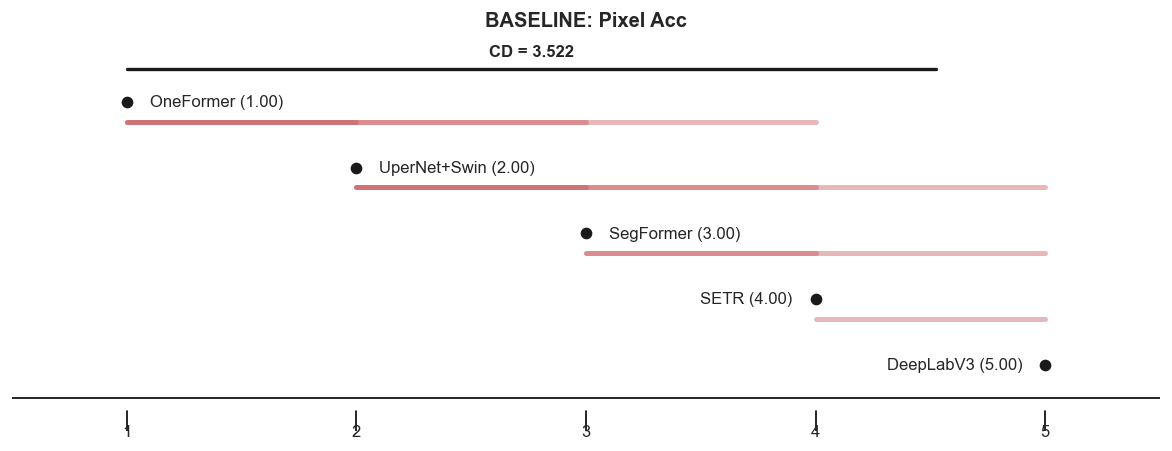


Cross-Architecture Comparison (FULL-RES)

  IoU: χ²=11.8644, p=0.018389, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 2.1666666666666665, 'SegFormer': 4.0, 'UperNet+Swin': 2.8333333333333335}
    Nemenyi CD (α=0.05): 3.5218


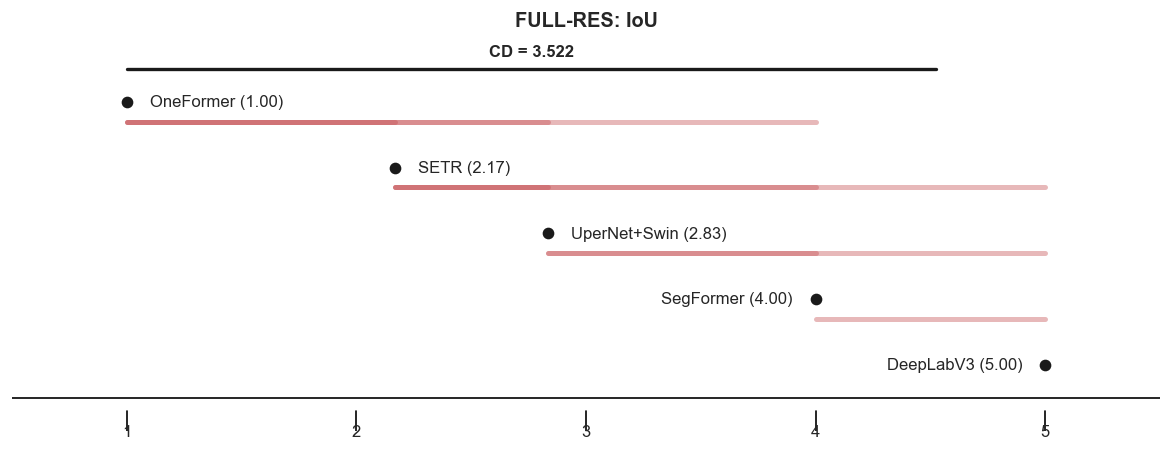


  F1: χ²=12.0000, p=0.017351, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 2.0, 'SegFormer': 4.0, 'UperNet+Swin': 3.0}
    Nemenyi CD (α=0.05): 3.5218


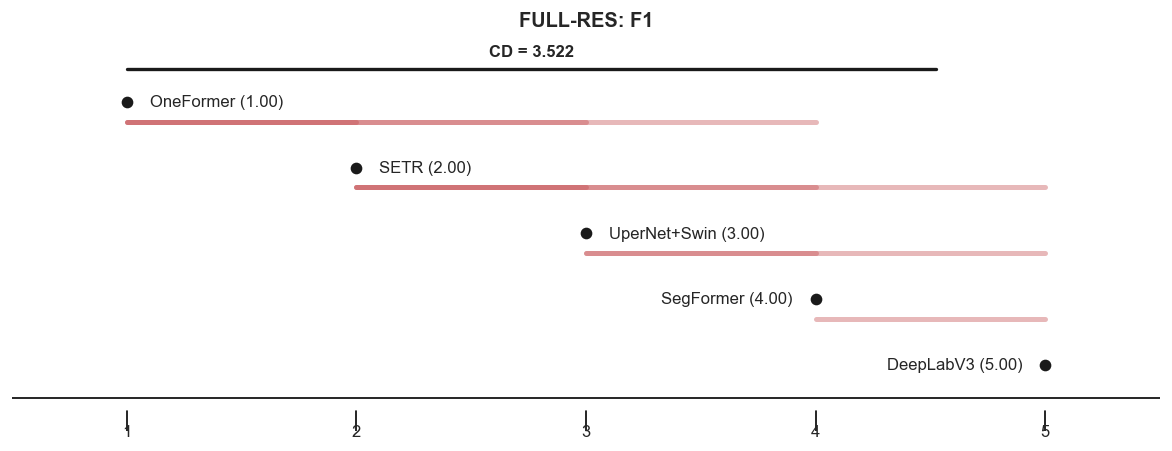


  B-IoU: χ²=11.4667, p=0.021791, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 2.6666666666666665, 'SegFormer': 4.0, 'UperNet+Swin': 2.3333333333333335}
    Nemenyi CD (α=0.05): 3.5218


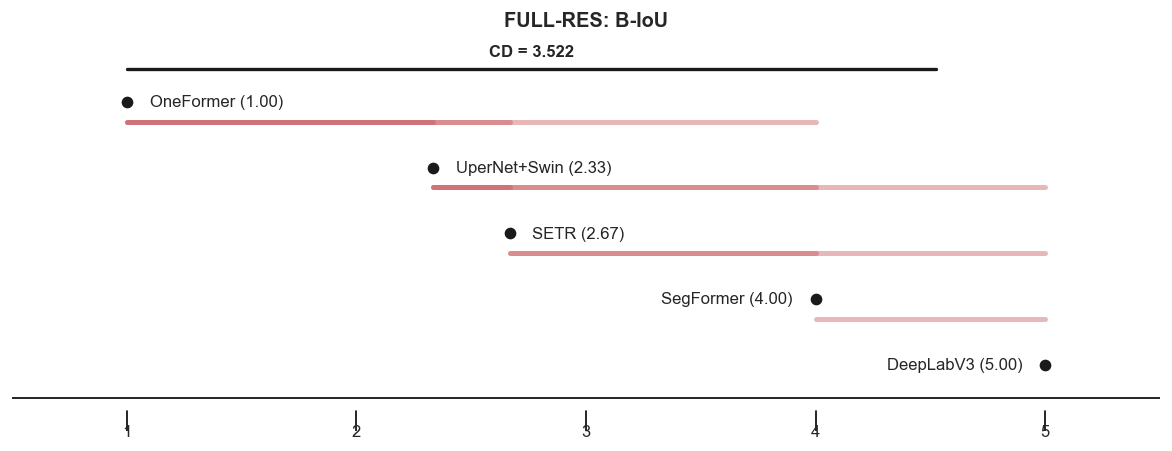


  Precision: χ²=9.8667, p=0.042735, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.3333333333333333, 'SETR': 2.0, 'SegFormer': 3.6666666666666665, 'UperNet+Swin': 3.0}
    Nemenyi CD (α=0.05): 3.5218


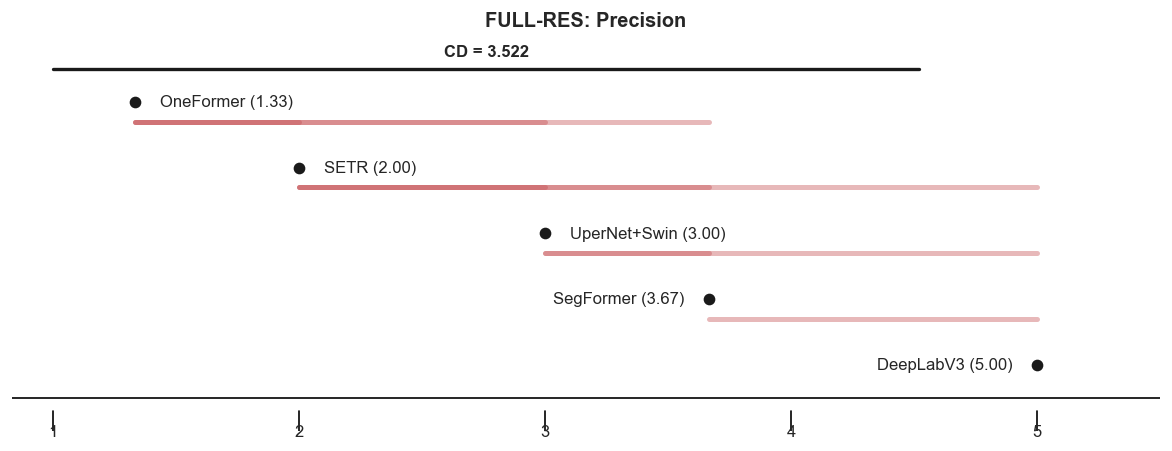


  Recall: χ²=9.8667, p=0.042735, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 3.0, 'SegFormer': 3.3333333333333335, 'UperNet+Swin': 2.6666666666666665}
    Nemenyi CD (α=0.05): 3.5218


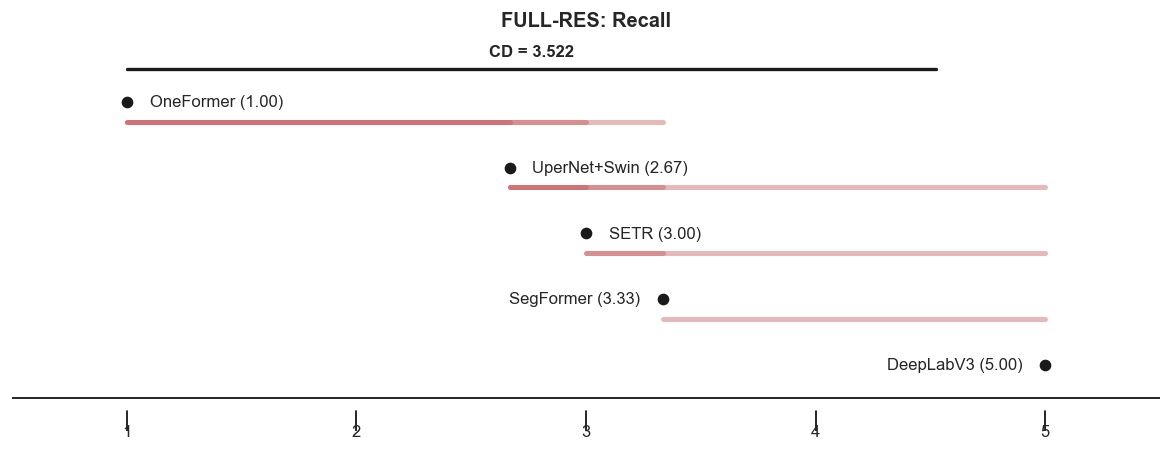


  Pixel Acc: χ²=12.0000, p=0.017351, Significant: YES
    Avg ranks: {'DeepLabV3': 5.0, 'OneFormer': 1.0, 'SETR': 2.0, 'SegFormer': 4.0, 'UperNet+Swin': 3.0}
    Nemenyi CD (α=0.05): 3.5218


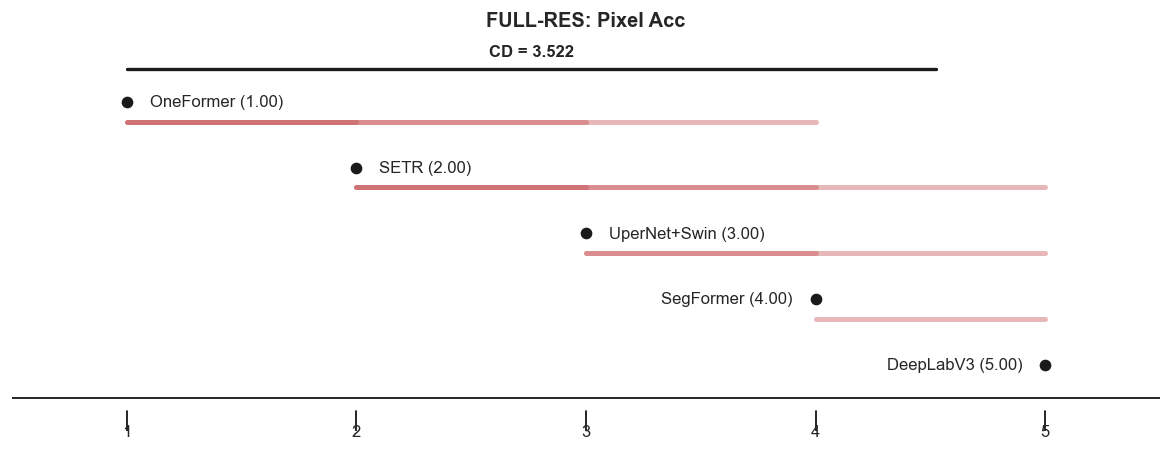

In [14]:
# ============================================================================
# Friedman Test + Nemenyi Post-Hoc
# ============================================================================

def run_friedman_test(df, metric_key, group_col="architecture", block_col="seed",
                      arch_filter=None):
    data = df.copy()
    if arch_filter:
        data = data[data["architecture"] == arch_filter]
    if metric_key not in data.columns:
        return {"error": f"Metric {metric_key} not found"}
    pivot = data.pivot_table(index=block_col, columns=group_col, values=metric_key)
    pivot = pivot.dropna(axis=1, how="all").dropna(axis=0, how="any")
    if pivot.shape[1] < 3:
        return {"error": f"Need >= 3 groups, got {pivot.shape[1]}"}
    if pivot.shape[0] < 3:
        return {"error": f"Need >= 3 blocks (seeds), got {pivot.shape[0]}"}
    groups = [pivot[col].values for col in pivot.columns]
    stat, p_value = stats.friedmanchisquare(*groups)
    return {"statistic": stat, "p_value": p_value, "significant": p_value < 0.05,
            "n_groups": pivot.shape[1], "n_blocks": pivot.shape[0],
            "groups": list(pivot.columns), "pivot": pivot}


def nemenyi_critical_difference(n_groups, n_blocks, alpha=0.05):
    q_table = {(2,0.05):1.960,(3,0.05):2.343,(4,0.05):2.569,(5,0.05):2.728,(6,0.05):2.850}
    q = q_table.get((n_groups, alpha))
    if q is None:
        from scipy.stats import studentized_range
        q = studentized_range.ppf(1 - alpha, n_groups, np.inf) / np.sqrt(2)
    return q * np.sqrt(n_groups * (n_groups + 1) / (6 * n_blocks))


def plot_critical_difference_diagram(avg_ranks, cd, title="CD Diagram", save_path=None):
    sorted_items = sorted(avg_ranks.items(), key=lambda x: x[1])
    names = [i[0] for i in sorted_items]
    ranks = [i[1] for i in sorted_items]
    n = len(names)
    fig, ax = plt.subplots(figsize=(10, 2.5 + 0.3 * n))
    ax.set_xlim(min(ranks) - 0.5, max(ranks) + 0.5)
    ax.set_ylim(0, n + 1)
    ax.axhline(y=0.5, color='black', linewidth=1)
    for r in range(1, n + 1):
        ax.axvline(x=r, ymin=0, ymax=0.05, color='black', linewidth=1)
        ax.text(r, 0.1, str(r), ha='center', va='top', fontsize=10)
    for i, (name, rank) in enumerate(sorted_items):
        y = n - i
        ax.plot(rank, y, 'ko', markersize=6)
        label = f"{name} ({rank:.2f})"
        ha = 'left' if i < n / 2 else 'right'
        offset = 0.1 if i < n / 2 else -0.1
        ax.text(rank + offset, y, label, va='center', ha=ha, fontsize=10)
    ax.plot([1, 1 + cd], [n + 0.5, n + 0.5], 'k-', linewidth=2)
    ax.text(1 + cd / 2, n + 0.7, f"CD = {cd:.3f}", ha='center', fontsize=10, fontweight='bold')
    for i in range(n):
        for j in range(i + 1, n):
            if abs(ranks[i] - ranks[j]) < cd:
                ax.plot([ranks[i], ranks[j]], [n - i - 0.3, n - i - 0.3], 'r-', linewidth=3, alpha=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


# Run Friedman tests
if not df_results.empty:
    for config_name in CONFIGS:
        print(f"\n{'='*60}")
        print(f"Cross-Architecture Comparison ({config_name.upper()})")
        print(f"{'='*60}")
        config_df = df_results[df_results["config"] == config_name]
        for metric_key, display_name in METRIC_DISPLAY.items():
            if metric_key not in config_df.columns:
                continue
            result = run_friedman_test(config_df, metric_key, group_col="architecture")
            if "error" in result:
                print(f"  {display_name}: {result['error']}")
                continue
            sig = "YES" if result["significant"] else "No"
            print(f"\n  {display_name}: \u03c7\u00b2={result['statistic']:.4f}, "
                  f"p={result['p_value']:.6f}, Significant: {sig}")
            if result["significant"]:
                pivot = result["pivot"]
                avg_ranks = pivot.rank(axis=1, ascending=False).mean().to_dict()
                cd = nemenyi_critical_difference(result["n_groups"], result["n_blocks"])
                print(f"    Avg ranks: {avg_ranks}")
                print(f"    Nemenyi CD (\u03b1=0.05): {cd:.4f}")
                plot_critical_difference_diagram(
                    avg_ranks, cd,
                    title=f"{config_name.upper()}: {display_name}",
                    save_path=str(EXPORT_DIR / f"cd_{config_name}_{display_name.lower().replace('-','_')}.pdf"))

In [15]:
# ============================================================================
# Paired Comparison: Baseline vs Full-Res per architecture
# ============================================================================

def paired_baseline_vs_fullres(df, metric_key, display_name):
    rows = []
    for arch in ARCHITECTURES:
        arch_df = df[df["architecture"] == arch]
        baseline = arch_df[arch_df["config"] == "baseline"].set_index("seed")[metric_key]
        fullres = arch_df[arch_df["config"] == "full-res"].set_index("seed")[metric_key]
        common_seeds = sorted(baseline.index.intersection(fullres.index))
        if not common_seeds:
            continue
        diffs = [fullres[s] - baseline[s] for s in common_seeds]
        rows.append({
            "Architecture": arch, "R": REDUCTION_FACTORS.get(arch, "?"),
            "Metric": display_name, "N Seeds": len(common_seeds),
            "Baseline Mean": np.mean(baseline.loc[common_seeds].values),
            "Full-Res Mean": np.mean(fullres.loc[common_seeds].values),
            "Mean \u0394": np.mean(diffs),
            "Seed Deltas": ", ".join([f"{d:+.4f}" for d in diffs]),
            "All Positive": "Yes" if all(d > 0 for d in diffs) else "No",
        })
    return pd.DataFrame(rows)


if not df_results.empty:
    print("Paired Comparison: Full-Res vs Baseline")
    print("=" * 80)
    for mk, dn in [("val_boundary_iou_class_1", "B-IoU"),
                    ("val_iou_class_1", "IoU"), ("val_f1_score_class_1", "F1")]:
        if mk in df_results.columns:
            df_paired = paired_baseline_vs_fullres(df_results, mk, dn)
            if not df_paired.empty:
                print(f"\n{dn}:")
                display(df_paired)

Paired Comparison: Full-Res vs Baseline

B-IoU:


,Architecture,R,Metric,N Seeds,Baseline Mean,Full-Res Mean,Mean Δ,Seed Deltas,All Positive
0,DeepLabV3,8,B-IoU,3,0.536933,0.546467,0.009533,"-0.0008, +0.0219, +0.0075",No
1,SETR,16,B-IoU,3,0.536433,0.640967,0.104533,"+0.1022, +0.1008, +0.1106",Yes
2,SegFormer,4,B-IoU,3,0.606867,0.613567,0.006700,"+0.0067, +0.0060, +0.0074",Yes
3,UperNet+Swin,4,B-IoU,3,0.638033,0.640100,0.002067,"+0.0086, +0.0029, -0.0053",No
4,OneFormer,4,B-IoU,3,0.670133,0.677367,0.007233,"+0.0034, +0.0073, +0.0110",Yes



IoU:


,Architecture,R,Metric,N Seeds,Baseline Mean,Full-Res Mean,Mean Δ,Seed Deltas,All Positive
0,DeepLabV3,8,IoU,3,0.830533,0.826333,-0.004200,"-0.0342, +0.0142, +0.0074",No
1,SETR,16,IoU,3,0.852533,0.887967,0.035433,"+0.0307, +0.0351, +0.0405",Yes
2,SegFormer,4,IoU,3,0.869133,0.871933,0.002800,"+0.0027, +0.0026, +0.0031",Yes
3,UperNet+Swin,4,IoU,3,0.887800,0.885033,-0.002767,"-0.0102, +0.0010, +0.0009",No
4,OneFormer,4,IoU,3,0.892200,0.896267,0.004067,"+0.0039, +0.0032, +0.0051",Yes



F1:


,Architecture,R,Metric,N Seeds,Baseline Mean,Full-Res Mean,Mean Δ,Seed Deltas,All Positive
0,DeepLabV3,8,F1,3,0.907367,0.904833,-0.002533,"-0.0205, +0.0085, +0.0044",No
1,SETR,16,F1,3,0.920400,0.940667,0.020267,"+0.0176, +0.0200, +0.0232",Yes
2,SegFormer,4,F1,3,0.929933,0.931567,0.001633,"+0.0016, +0.0015, +0.0018",Yes
3,UperNet+Swin,4,F1,3,0.940533,0.938967,-0.001567,"-0.0058, +0.0005, +0.0006",No
4,OneFormer,4,F1,3,0.943033,0.945267,0.002233,"+0.0021, +0.0018, +0.0028",Yes



B-IoU Bootstrap 95% CIs:


,Architecture,Config,CI String
0,DeepLabV3,Baseline,"0.5369 [0.4988, 0.5586]"
1,DeepLabV3,Full-Res,"0.5465 [0.5207, 0.5661]"
2,OneFormer,Baseline,"0.6701 [0.6649, 0.6768]"
3,OneFormer,Full-Res,"0.6774 [0.6721, 0.6878]"
4,SETR,Baseline,"0.5364 [0.5108, 0.5534]"
5,SETR,Full-Res,"0.6410 [0.6116, 0.6640]"
6,SegFormer,Baseline,"0.6069 [0.5945, 0.6144]"
7,SegFormer,Full-Res,"0.6136 [0.6005, 0.6211]"
8,UperNet+Swin,Baseline,"0.6380 [0.6311, 0.6457]"
9,UperNet+Swin,Full-Res,"0.6401 [0.6320, 0.6543]"


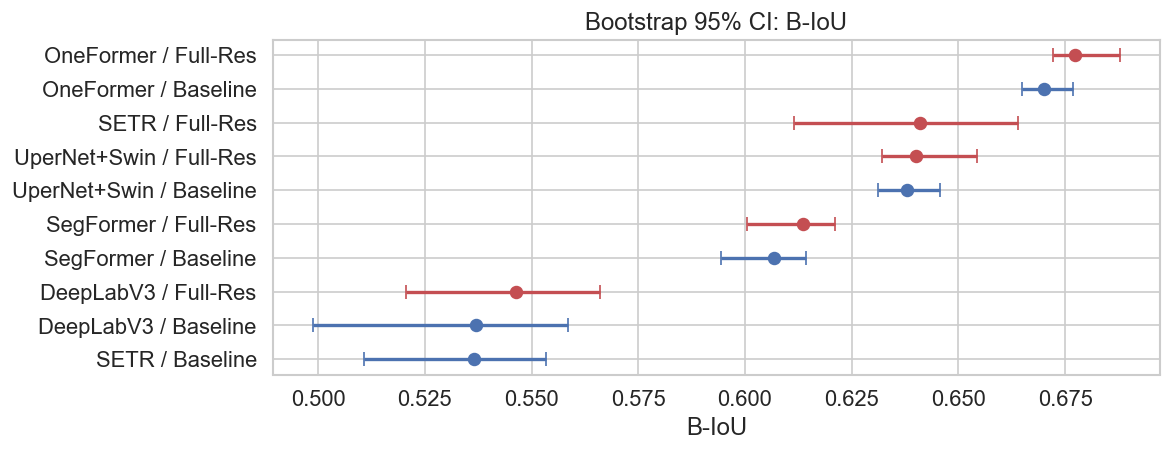


IoU Bootstrap 95% CIs:


,Architecture,Config,CI String
0,DeepLabV3,Baseline,"0.8305 [0.8150, 0.8398]"
1,DeepLabV3,Full-Res,"0.8263 [0.8056, 0.8442]"
2,OneFormer,Baseline,"0.8922 [0.8858, 0.9015]"
3,OneFormer,Full-Res,"0.8963 [0.8897, 0.9047]"
4,SETR,Baseline,"0.8525 [0.8465, 0.8586]"
5,SETR,Full-Res,"0.8880 [0.8832, 0.8937]"
6,SegFormer,Baseline,"0.8691 [0.8612, 0.8803]"
7,SegFormer,Full-Res,"0.8719 [0.8639, 0.8829]"
8,UperNet+Swin,Baseline,"0.8878 [0.8846, 0.8927]"
9,UperNet+Swin,Full-Res,"0.8850 [0.8759, 0.8937]"


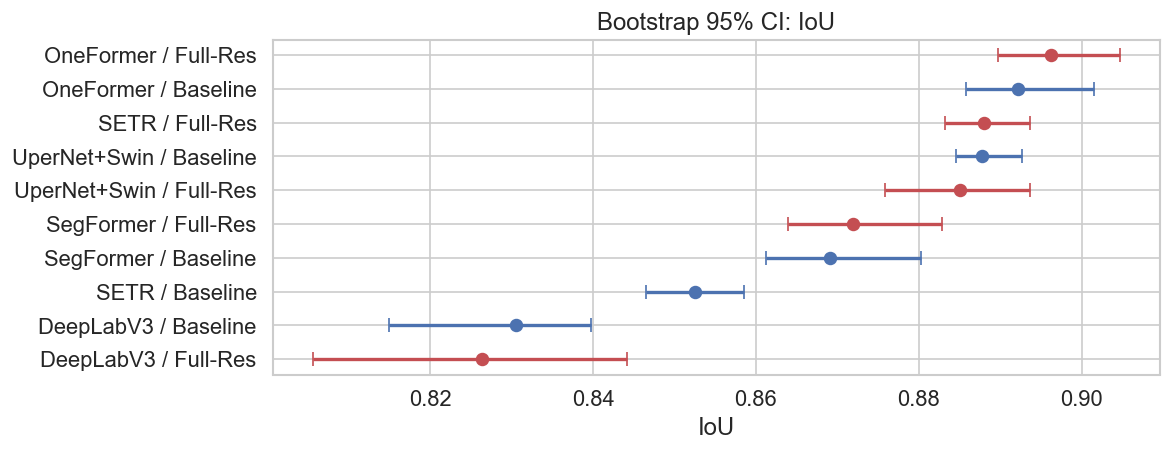


F1 Bootstrap 95% CIs:


,Architecture,Config,CI String
0,DeepLabV3,Baseline,"0.9074 [0.8981, 0.9129]"
1,DeepLabV3,Full-Res,"0.9048 [0.8924, 0.9155]"
2,OneFormer,Baseline,"0.9430 [0.9395, 0.9482]"
3,OneFormer,Full-Res,"0.9453 [0.9416, 0.9500]"
4,SETR,Baseline,"0.9204 [0.9169, 0.9239]"
5,SETR,Full-Res,"0.9407 [0.9380, 0.9439]"
6,SegFormer,Baseline,"0.9299 [0.9254, 0.9363]"
7,SegFormer,Full-Res,"0.9316 [0.9270, 0.9378]"
8,UperNet+Swin,Baseline,"0.9405 [0.9387, 0.9433]"
9,UperNet+Swin,Full-Res,"0.9390 [0.9338, 0.9438]"


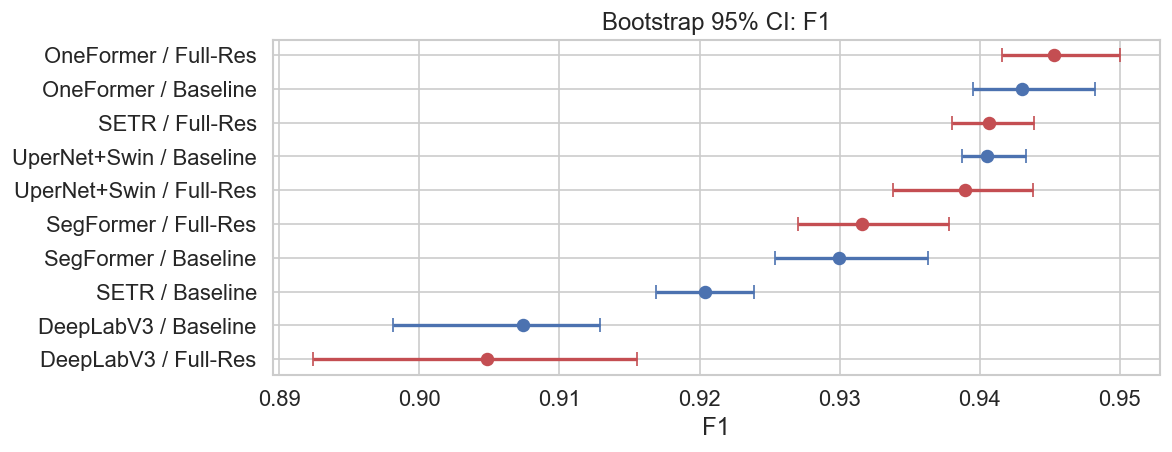

In [16]:
# ============================================================================
# Bootstrap 95% Confidence Intervals
# ============================================================================

def bootstrap_ci(values, n_bootstrap=10000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    n = len(values)
    boot_means = np.array([np.mean(rng.choice(values, size=n, replace=True))
                           for _ in range(n_bootstrap)])
    alpha = (1 - ci) / 2
    return (float(np.mean(values)),
            float(np.percentile(boot_means, alpha * 100)),
            float(np.percentile(boot_means, (1 - alpha) * 100)))


def compute_all_bootstrap_cis(df, metrics=None, n_bootstrap=10000):
    if df.empty:
        return pd.DataFrame()
    if metrics is None:
        metrics = [m for m in KEY_METRICS if m in df.columns]
    rows = []
    for (arch, cfg), group in df.groupby(["architecture", "config"]):
        for mk in metrics:
            if mk not in group.columns:
                continue
            values = group[mk].dropna().values
            if len(values) < 2:
                continue
            mean, lower, upper = bootstrap_ci(values, n_bootstrap=n_bootstrap)
            dn = METRIC_DISPLAY.get(mk, mk)
            rows.append({"Architecture": arch,
                         "Config": "Baseline" if cfg == "baseline" else "Full-Res",
                         "Metric": dn, "Mean": mean,
                         "95% CI Lower": lower, "95% CI Upper": upper,
                         "CI Width": upper - lower,
                         "CI String": f"{mean:.4f} [{lower:.4f}, {upper:.4f}]"})
    return pd.DataFrame(rows)


def plot_bootstrap_cis(df_ci, metric_name, title=None, save_path=None):
    subset = df_ci[df_ci["Metric"] == metric_name].copy()
    if subset.empty:
        return
    subset["label"] = subset["Architecture"] + " / " + subset["Config"]
    subset = subset.sort_values("Mean", ascending=True).reset_index(drop=True)
    colors = ['#4C72B0' if 'Baseline' in l else '#C44E52' for l in subset["label"]]
    fig, ax = plt.subplots(figsize=(10, max(4, len(subset) * 0.4)))
    for i, row in subset.iterrows():
        c = colors[i]
        ax.errorbar(row["Mean"], i,
                    xerr=[[row["Mean"] - row["95% CI Lower"]],
                          [row["95% CI Upper"] - row["Mean"]]],
                    fmt='none', ecolor=c, elinewidth=2, capsize=4)
        ax.scatter(row["Mean"], i, c=c, s=50, zorder=5)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset["label"])
    ax.set_xlabel(metric_name)
    ax.set_title(title or f"Bootstrap 95% CI: {metric_name}")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


if not df_results.empty:
    df_ci = compute_all_bootstrap_cis(df_results)
    if not df_ci.empty:
        for mn in ["B-IoU", "IoU", "F1"]:
            ci_sub = df_ci[df_ci["Metric"] == mn]
            if not ci_sub.empty:
                print(f"\n{mn} Bootstrap 95% CIs:")
                display(ci_sub[["Architecture", "Config", "CI String"]].reset_index(drop=True))
                plot_bootstrap_cis(df_ci, mn,
                    save_path=str(EXPORT_DIR / f"ci_{mn.lower().replace('-','_')}.pdf"))

---
## Part 3: Publication Exports

In [17]:
# ============================================================================
# LaTeX Table Export (for manuscript Table 2)
# ============================================================================

def create_latex_main_results(df_agg):
    """Generate LaTeX for main results table matching the new manuscript structure."""
    if df_agg.empty:
        return "% No data"
    
    # New column order
    metrics = ["val_iou_class_1", "val_f1_score_class_1", "val_precision_class_1", 
               "val_recall_class_1", "val_pixel_accuracy", "val_boundary_iou_class_1"]
    arch_order = ARCHITECTURES
    config_order = ["baseline", "full-res"]

    # Find best and second best per metric
    best = {}
    second_best = {}
    for m in metrics:
        mc = f"{m}_mean"
        if mc in df_agg.columns:
            sorted_vals = df_agg[mc].dropna().sort_values(ascending=False).values
            if len(sorted_vals) > 0:
                best[m] = sorted_vals[0]
            if len(sorted_vals) > 1:
                # Find the first value strictly less than the best (to handle ties if any, though unlikely with floats)
                unique_vals = sorted(list(set(sorted_vals)), reverse=True)
                if len(unique_vals) > 1:
                    second_best[m] = unique_vals[1]

    # Pre-calculate deltas for B-IoU
    deltas = {}
    biou_col = "val_boundary_iou_class_1_mean"
    if biou_col in df_agg.columns:
        for arch in arch_order:
            arch_rows = df_agg[df_agg["architecture"] == arch]
            base_row = arch_rows[arch_rows["config"] == "baseline"]
            full_row = arch_rows[arch_rows["config"] == "full-res"]
            if not base_row.empty and not full_row.empty:
                deltas[arch] = full_row.iloc[0][biou_col] - base_row.iloc[0][biou_col]

    lines = []
    for arch in arch_order:
        r = REDUCTION_FACTORS.get(arch, '?')
        arch_rows = df_agg[df_agg["architecture"] == arch]
        
        for cfg in config_order:
            row = arch_rows[arch_rows["config"] == cfg]
            if row.empty:
                continue
            row = row.iloc[0]
            cfg_display = "Baseline" if cfg == "baseline" else "Full-Res"
            
            # First two columns
            if cfg == "baseline":
                cells = [f"    \\multirow{{2}}{{*}}{{{arch} ($R{{=}}{r}$)}}\n        & {cfg_display} "]
            else:
                cells = [f"        & {cfg_display} "]
                
            # Metric columns
            for m in metrics:
                mc, sc = f"{m}_mean", f"{m}_std"
                if mc in row.index and not pd.isna(row[mc]):
                    val_str = f"{row[mc]:.4f} \\pm {row[sc]:.4f}"
                    
                    # Apply formatting based on rank
                    if m in best and abs(row[mc] - best[m]) < 1e-6:
                        val_str = f"\\mathbf{{{val_str}}}"
                    elif m in second_best and abs(row[mc] - second_best[m]) < 1e-6:
                        val_str = f"\\underline{{{val_str}}}"
                    else:
                        val_str = f"${val_str}$"
                        
                    cells.append(f" & {val_str}")
                else:
                    cells.append(" & ---")
            
            # Delta column (only for Full-Res row)
            if cfg == "full-res" and arch in deltas:
                delta_val = deltas[arch]
                delta_str = f"{delta_val:+.4f}"
                
                # Check if it's the max delta (SETR is usually the max)
                is_max_delta = True
                for other_arch, other_delta in deltas.items():
                    if other_delta > delta_val + 1e-6:
                        is_max_delta = False
                        break
                        
                if is_max_delta:
                    delta_str = f"\\mathbf{{{delta_str}}}"
                else:
                    # Check if second max
                    all_deltas = sorted(list(deltas.values()), reverse=True)
                    if len(all_deltas) > 1 and abs(delta_val - all_deltas[1]) < 1e-6:
                        delta_str = f"\\underline{{{delta_str}}}"
                    else:
                        delta_str = f"${delta_str}$"
                        
                cells.append(f" & {delta_str}")
            else:
                cells.append(" & ")
                
            cells.append(" \\\\")
            lines.append("".join(cells))
        lines.append("    \\midrule")
    
    if lines and lines[-1] == "    \\midrule":
        lines.pop() # Remove trailing midrule
        
    return "\n".join(lines)


if not df_results.empty and not df_agg.empty:
    latex_body = create_latex_main_results(df_agg)
    print("LaTeX table body (paste into tab:main_results in main.tex):")
    print("=" * 60)
    print(latex_body)
    with open(EXPORT_DIR / "table2_body.tex", "w") as f:
        f.write(latex_body)
    print(f"\nSaved to {EXPORT_DIR / 'table2_body.tex'}")

LaTeX table body (paste into tab:main_results in main.tex):
    \multirow{2}{*}{DeepLabV3 ($R{=}8$)}
        & Baseline  & $0.8305 \pm 0.0135$ & $0.9074 \pm 0.0081$ & $0.9035 \pm 0.0138$ & $0.9114 \pm 0.0059$ & $0.9530 \pm 0.0061$ & $0.5369 \pm 0.0331$ &  \\
        & Full-Res  & $0.8263 \pm 0.0195$ & $0.9048 \pm 0.0117$ & $0.9036 \pm 0.0137$ & $0.9061 \pm 0.0105$ & $0.9533 \pm 0.0045$ & $0.5465 \pm 0.0233$ & \underline{+0.0095} \\
    \midrule
    \multirow{2}{*}{SETR ($R{=}16$)}
        & Baseline  & $0.8525 \pm 0.0061$ & $0.9204 \pm 0.0035$ & $0.9307 \pm 0.0080$ & $0.9104 \pm 0.0014$ & $0.9608 \pm 0.0014$ & $0.5364 \pm 0.0226$ &  \\
        & Full-Res  & $0.8880 \pm 0.0053$ & $0.9407 \pm 0.0030$ & $0.9472 \pm 0.0067$ & $0.9343 \pm 0.0080$ & $0.9711 \pm 0.0006$ & $0.6410 \pm 0.0268$ & \mathbf{+0.1045} \\
    \midrule
    \multirow{2}{*}{SegFormer ($R{=}4$)}
        & Baseline  & $0.8691 \pm 0.0100$ & $0.9299 \pm 0.0057$ & $0.9312 \pm 0.0046$ & $0.9287 \pm 0.0075$ & $0.9653 \pm 0.0014

In [18]:
# ============================================================================
# Best Architecture Selection (for Phase 2 & 3)
# ============================================================================

if not df_results.empty:
    biou_key = "val_boundary_iou_class_1"
    if biou_key in df_results.columns:
        means = df_results.groupby(["architecture", "config"])[biou_key].mean().unstack()
        if "baseline" in means.columns and "full-res" in means.columns:
            delta = means["full-res"] - means["baseline"]
            print("B-IoU Improvement Ranking (Full-Res - Baseline):")
            print("=" * 50)
            for arch in delta.sort_values(ascending=False).index:
                r = REDUCTION_FACTORS.get(arch, '?')
                print(f"  {arch} (R={r}): \u0394 = {delta[arch]:+.4f}")
            best_arch = delta.idxmax()
            print(f"\n>> Best architecture for Phase 2 & 3: {best_arch} (\u0394 B-IoU = {delta[best_arch]:.4f})")
else:
    print("No results for architecture selection.")

B-IoU Improvement Ranking (Full-Res - Baseline):
  SETR (R=16): Δ = +0.1045
  DeepLabV3 (R=8): Δ = +0.0095
  OneFormer (R=4): Δ = +0.0072
  SegFormer (R=4): Δ = +0.0067
  UperNet+Swin (R=4): Δ = +0.0021

>> Best architecture for Phase 2 & 3: SETR (Δ B-IoU = 0.1045)
